# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

In [53]:
#%pip install wordcloud scikit-learn
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as sklearn_stop_words

df = pd.read_csv('Starbucks_Reviews.csv')

df.head()

,name,location,Date,Rating,Review,Image_Links
0,Helen,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...,['No Images']
1,Courtney,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...,['No Images']
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...,['https://media.consumeraffairs.com/files/cach...
3,Taylor,"Seattle, WA","Reviewed May 26, 2023",5.0,Me and my friend were at Starbucks and my card...,['No Images']
4,Tenessa,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,I’m on this kick of drinking 5 cups of warm wa...,['https://media.consumeraffairs.com/files/cach...


Positive Reviews


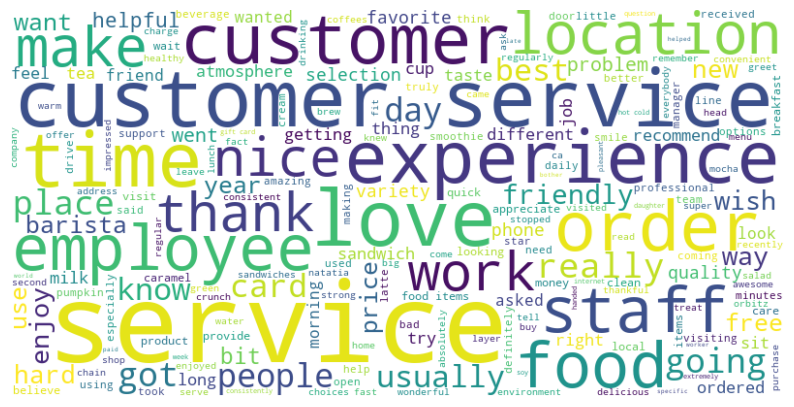

In [54]:
# Define additional stopwords to remove
# {'food', 'restaurant', 'good', 'great', 'best', 'excellent', 'amazing', 'bad', 'terrible', 'place'}
additional_stopwords = {'good', 'great', 'coffee', 'drink', 'drinks', 'starbucks', 'store'}

# Separate positive and negative reviews
positive_reviews = ' '.join(df[df['Rating'] >= 4]['Review'].astype(str))

# Tokenize the words
postive_words = positive_reviews.lower().split()
    
# Remove punctuation and stopwords (including additional stopwords)
postive_words = [word.strip(string.punctuation) for word in postive_words if word.isalnum() and word not in sklearn_stop_words and word not in additional_stopwords]
    
# Generate the word cloud
print('Positive Reviews')
wordcloud = WordCloud(width=800, height=400, background_color ='white').generate(' '.join(postive_words))
plt.figure(figsize=(10, 7)) 
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


First off is a word cloud showing the most popular phrases used in positive reviews. It's set for reviews above 3 stars to be considered positive.  
Many words are listed, though many of the more standout ones include Service (which is listed twice for some reason), experience, staff, and other details connected to staff personalities.  
There is also praise for the food and location, though drinks and related words were omitted due to their common use.

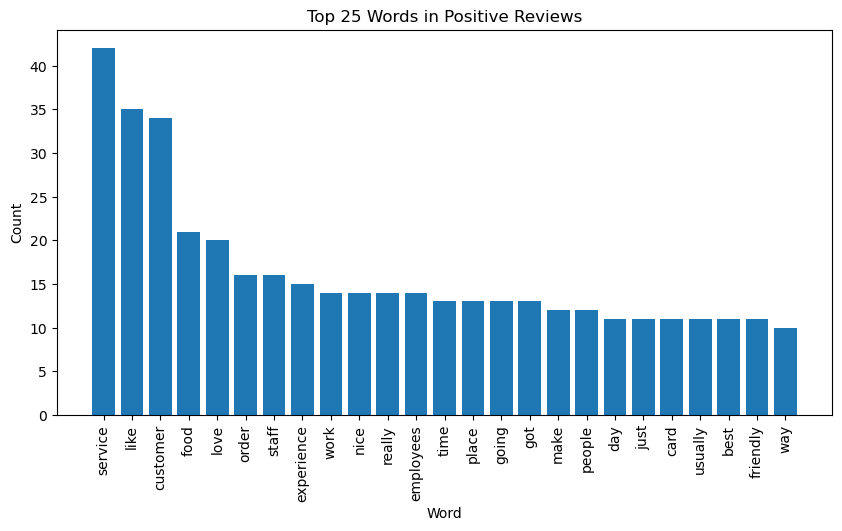

In [55]:
positive_word_freq = Counter(postive_words)
positive_common_words = positive_word_freq.most_common(25)
    
# Convert to DataFrame for plotting
positive_freq_df = pd.DataFrame(positive_common_words, columns=['Word', 'Frequency'])
    
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(positive_freq_df['Word'], positive_freq_df['Frequency'])
ax.set_title(f'Top 25 Words in Positive Reviews')
ax.set_xlabel('Word')
ax.set_ylabel('Count')
plt.xticks(rotation=90)
plt.show()

Next is a bar graph detailing the same most common positive words. This graph is rather similar to the word cloud, though I find it far easier to visualize.  
Service is praised, and employee personality seems to be a consistent factor in these reviews.

In [56]:
#%pip install textblob
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from textblob import TextBlob
import plotly.express as px

# Sentiment calculations
df['calc_sentiment'] = df['Review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['subjectivity'] = df['Review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
df['abs_sentiment'] = df['calc_sentiment'].abs()

# Optional: Make sentiment a category to suppress warning
df['Rating'] = df['Rating'].astype(str)

# Plot
fig = px.scatter(
    df, 
    x='calc_sentiment', 
    y='subjectivity', 
    hover_data=['Review'],
    color='Rating',
    size='abs_sentiment',
    size_max=15,
    title='Sentiment Polarity vs Subjectivity',
    hover_name='location',
    labels={'sentiment': 'Sentiment Polarity', 'subjectivity': 'Subjectivity'}
)

fig.update_layout(xaxis_title='Sentiment', height=500)
fig.show()


Finally, a sentiment map. This was interesting, as it shows some discrepancies ratings otherwise wouldnt. For example, low rating reviews providing praise, or review scores that depend entirely on the person or circumstances indicated by a high subjectivity.  
It's not perfect, but the groupings give some interesting insights, and the occasional outlier such as a positive 1-star are often worth investigating further.